In [1]:
# Import the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

print(" Libraries imported successfully!")

 Libraries imported successfully!


In [2]:
# Load the Dataset

df = pd.read_csv('Alibaba Stock Data.csv')

print(" Alibaba Stock Data uploaded successfully!")
print(f"\nDataset loaded! Shape: {df.shape}")
print(f"\nRows: {df.shape[0]}, Columns: {df.shape[1]}")

 Alibaba Stock Data uploaded successfully!

Dataset loaded! Shape: (1892, 7)

Rows: 1892, Columns: 7


In [3]:
# Explore the Data
# Display first 5 rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,Date,Open,High,Low,Close,Adj Close,Volume
0,9/19/2014,92.699997,99.699997,89.949997,93.889999,93.889999,271879400
1,9/22/2014,92.699997,92.949997,89.500000,89.889999,89.889999,66657800
2,9/23/2014,88.940002,90.480003,86.620003,87.169998,87.169998,39009800
3,9/24/2014,88.470001,90.570000,87.220001,90.570000,90.570000,32088000
4,9/25/2014,91.089996,91.500000,88.500000,88.919998,88.919998,28598000


In [4]:
# Check the column names and data types

print(" Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("\n Statistical Summary:")
df.describe()

 Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1892 entries, 0 to 1891
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1892 non-null   str    
 1   Open       1892 non-null   float64
 2   High       1892 non-null   float64
 3   Low        1892 non-null   float64
 4   Close      1892 non-null   float64
 5   Adj Close  1892 non-null   float64
 6   Volume     1892 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 103.6 KB
None


 Statistical Summary:


,Open,High,Low,Close,Adj Close,Volume
count,1892.000000,1892.000000,1892.000000,1892.000000,1892.000000,1.892000e+03
mean,153.547341,155.355785,151.427648,153.416342,153.416342,1.843771e+07
std,59.621322,60.184275,58.830174,59.548424,59.548424,1.317609e+07
min,57.299999,58.650002,57.200001,57.389999,57.389999,3.775300e+06
25%,96.414999,97.712502,95.565001,96.667500,96.667500,1.148042e+07
50%,160.809998,162.820007,158.610001,160.279999,160.279999,1.546250e+07
75%,191.140003,193.807503,189.090004,191.479999,191.479999,2.099822e+07
max,313.500000,319.320007,308.910004,317.140015,317.140015,2.718794e+08


**Summary of the above**
- The dataset has 1892 records(rows) and 7 features(columns).
- The average stock price throughout the period was approximately USD 153.
- The standard deviation of the 'Close' price was USD 59, indicating high volatility in the stock. Higher Standard deviation = more risk/variability.
- 25% of prices are below USD 96.
- 75% of prices are below USD 191.
- The median is close to the mean which means the distribution is fairly balanced.
- The standard deviation(59) is large relative to mean(153) which means the stock highly volatile.

In [5]:
# Check for missing values

print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing Values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Total missing values: 0


- There are no missing values in the dataset.

In [6]:
# Check for duplicates

duplicate_rows = df[df.duplicated()]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")

Number of duplicate rows: 0


- There are no duplicate rows in the dataset.

**Daily Returns Over Time**

In [7]:
df['Return'] = df['Adj Close'].pct_change()

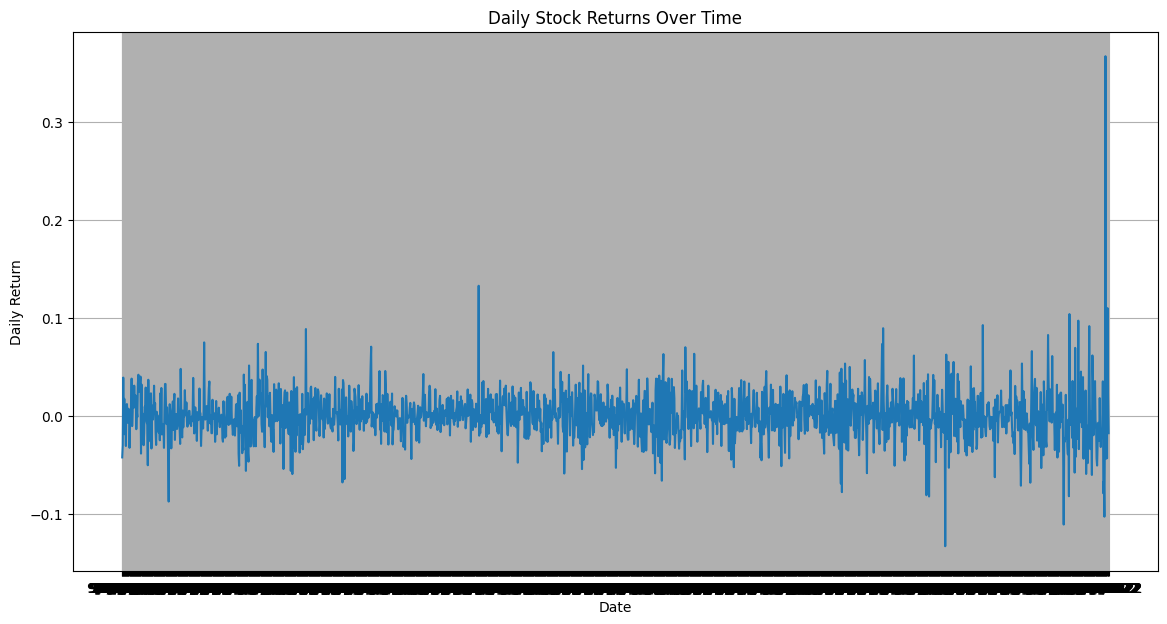

In [8]:
plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Return'])
plt.title('Daily Stock Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.grid(True)
plt.show()

- The daily returns plot showed the day-to-day percentage changes, highlighting the short-term fluctuations and magnitude of price movements.
- Volatility Clusters; Most of the data stays tightly packed around the 0.0 mark, which is normal for daily stock movements.
- There are periods where the "spikes" become wider, indicating times of higher market volatility.

**Rolling Average of Returns**

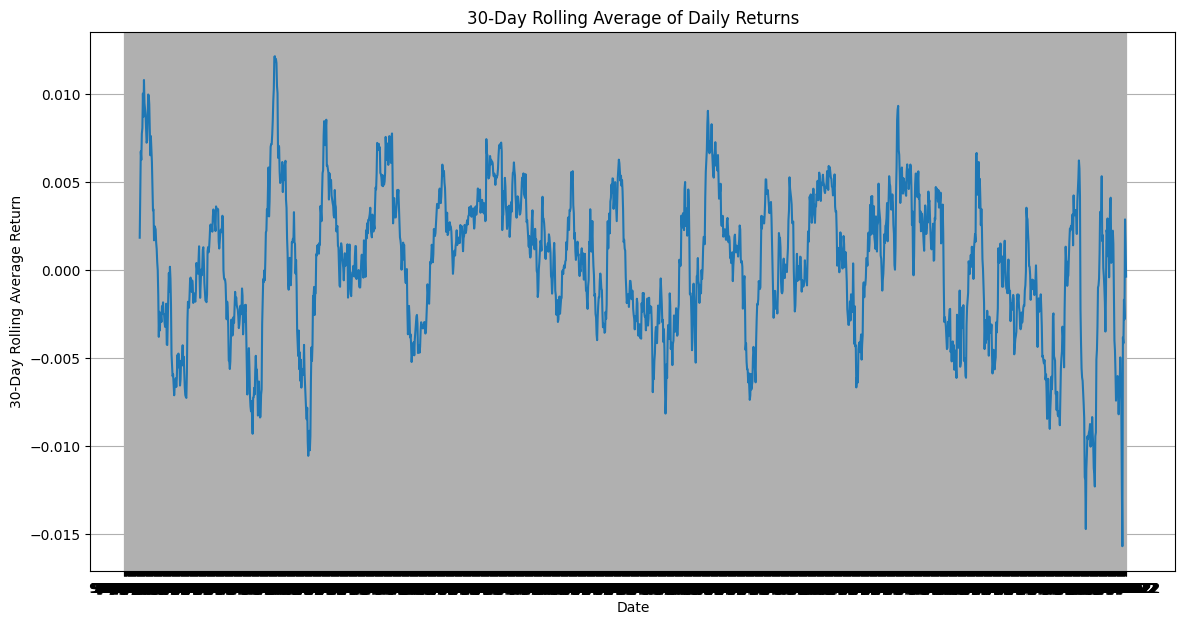

In [9]:
df['Rolling_Return_Avg'] = df['Return'].rolling(window=30).mean()

plt.figure(figsize=(14, 7))
plt.plot(df['Date'], df['Rolling_Return_Avg'])
plt.title('30-Day Rolling Average of Daily Returns')
plt.xlabel('Date')
plt.ylabel('30-Day Rolling Average Return')
plt.grid(True)
plt.show()

- This smoothed plot helped to identify longer-term trends in returns, filtering out daily noise and providing insight into sustained periods of positive or negative performance.
- The fluctuating blue line indicates how the average returns varied during this period.
- Values above 0.000 represent positive average returns (gains), while values below 0.000 represent negative average returns (losses).

**Time-Series Visualization**
- It helps to check Long-term trend (up/down) and Sudden spikes or crashes.

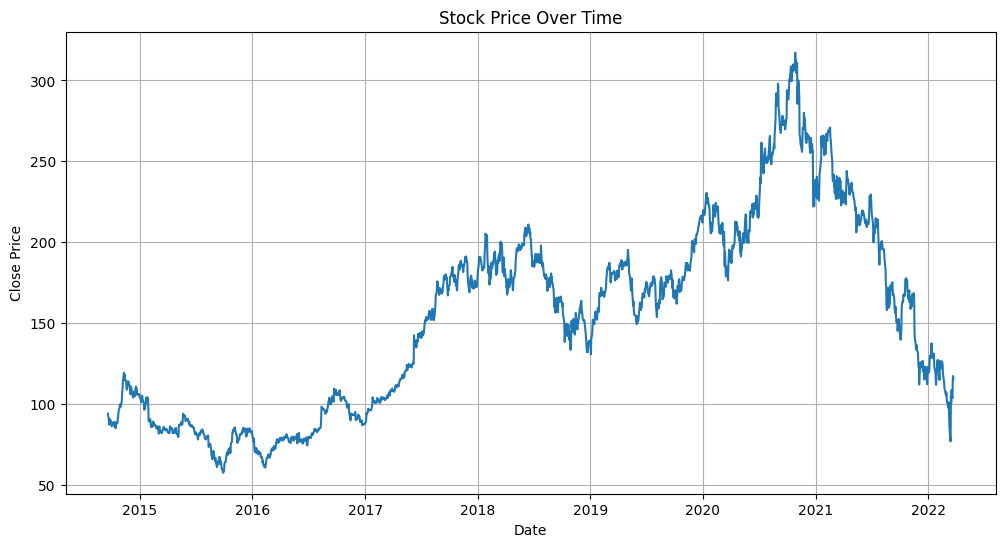

In [10]:
df['Date'] = pd.to_datetime(df['Date'])

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'])
plt.title("Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()

- From 2015 to mid 2017, the 'Close' price generally ranged between USD 50 and 100.
- From late 2017 to early 2021, a significant upward trend was observed with the price peaking above USD 200 in early 2021.
- From early 2021 onwards, the stock experienced a sharp decline returning to the USD 100-150 range by early 2022.

**Volatility Analysis**
- It helps us to check Volume spikes (news/events) and Trend confirmation.

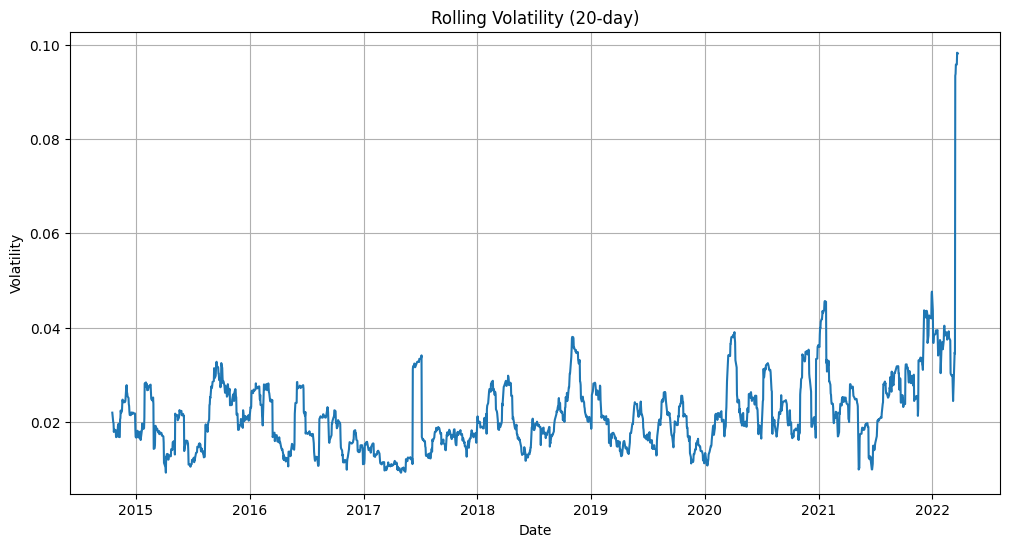

In [11]:

# Calculate daily returns
df['Return'] = df['Adj Close'].pct_change()

# Calculate rolling volatility
df['Volatility'] = df['Return'].rolling(20).std()

plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Volatility'])
plt.title("Rolling Volatility (20-day)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

- Rolling Volatility (20-day); Volatility typically fluctuated between 0.01 and 0.04 for most of the period.
- Spikes; Notable temporary increases in volatility occurred around late 2017, early 2019, early 2020 and early 2021.
- Turbulence in 2022; A sharp increase in volatility to nearly 0.10 was observed in 2022, suggesting a period of significant market turbulence or rapid price changes.

Price Movement Visualization
- It helps us to know Market psychology and Daily price movement.

In [12]:
# Price Movement Visualization using a Candlestick Chart
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(
    x=df['Date'],
    open=df['Open'],
    high=df['High'],
    low=df['Low'],
    close=df['Close']
)])
fig.show()

- The red and green lines typically indicate price changes over specific time intervals, such as days or weeks.
- From 2015 to late 2021, the stock experienced a substantial upward trend, with its value increasing significantly from under 50 to nearly 300 on the y axis.
- Around late 2021 and extending into 2022, there was a sharp correctionor decline in value, bringing the price down considerably.
- Such movements can indicate profit-taking or significant sell pressure in the market.

**Volume Analysis**
- It helps us to know Volume spikes (news/events) and Trend confirmation.

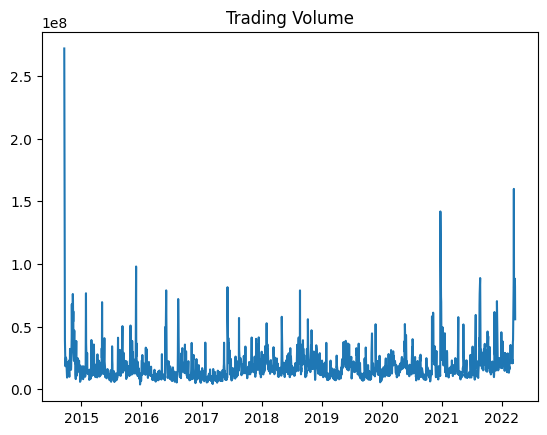

In [13]:
plt.plot(df['Date'], df['Volume'])
plt.title("Trading Volume")
plt.show()

- The trading volume plot visualized daily trading activity, which can be indicative of market interest or significant events.
- The graph shows highly volatile trading activity across the years. The volume generally hovers at a low level (below 0.5 units), but experiences several sharp, momentary spikes that reaches levels up to 2.5 units.

**Correlation Analysis**
- It helps us to Identify redundant features and understand relationships.


<Axes: >

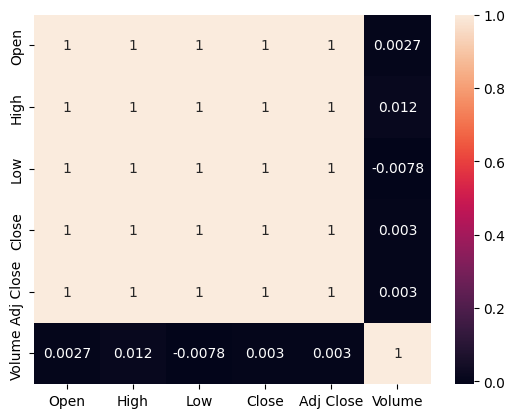

In [14]:
# Investigate relationships between volume and price movements.

corr = df[['Open','High','Low','Close','Adj Close','Volume']].corr()
sns.heatmap(corr, annot=True)

- High Correlation; As expected, 'Open', 'High', 'Low', 'Close' and 'Adj Close' prices showed very high positive correlations (close to 1.0) with each other.
- Volume; 'Volume' had a very low correlation with price movements,indicating that daily trading volume is not strongly linearly related to daily price changes.

**Return Calculation**


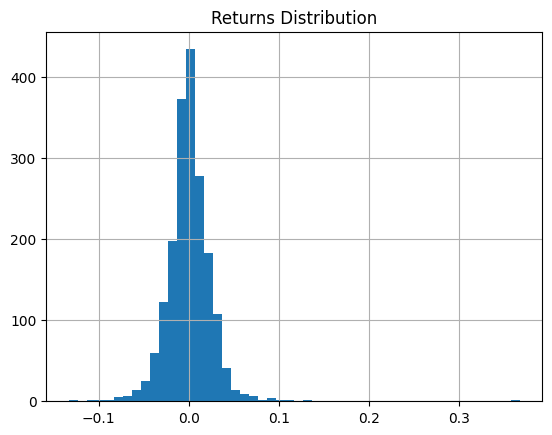

In [15]:
# Compute daily returns and cumulative returns to measure investment performance.

df['Return'] = df['Adj Close'].pct_change()

df['Return'].hist(bins=50)
plt.title("Returns Distribution")
plt.show()

- A histogram of daily returns provides insight into the frequency and spread of returns, which can be useful for risk assessment.
- The tall bars clustered around 0.0 mark indicate that the most frequent outcome for this specific investment was a return close to zero.
- The distribution appears relatively normal but peaked.

**Monthly check**

<Axes: xlabel='Month'>

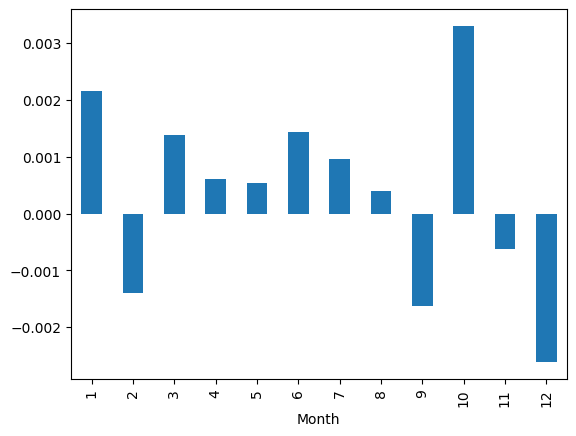

In [16]:
df['Month'] = df['Date'].dt.month
df.groupby('Month')['Return'].mean().plot(kind='bar')

- A bar plot of average monthly returns helps to identify any seasonal patterns.
- The stocks are traded most during the month of October and least traded during the month of December.

**Outliers Detection**

<Axes: >

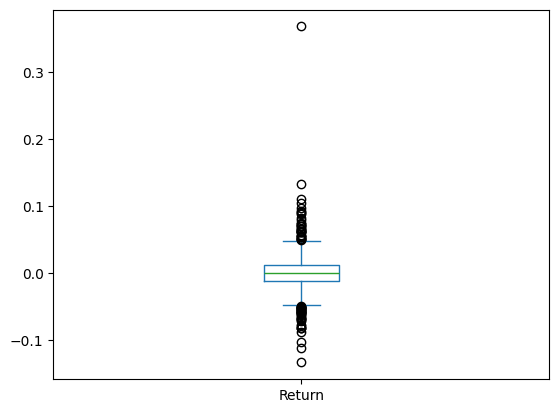

In [17]:
# Check for outliers

df['Return'].plot(kind='box')

- We have outliers which shows we have extreme price movements for a single day either unsually large negative returns (spikes) or unsually large negative returns (crashes or significant drops).
- Negative Outliers; The dots below the lower whisker represent days with unusually large negative returns (significant price crashes or drops).
- Positive Outliers; The dots above the upper whisker represent days with unusually large positive returns (significant price spikes).
- The presence of these outliers suggests that the stock experiences periods of extreme price movements, which is common in financial markets and can be due to various factors like news events, economic announcements, or market sentiment.

**Machine Learning Models**

**Feature Engineering for Time Series Models**

In [18]:
# Ensure 'Date' column is in datetime format and set as index
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

# Create Lagged Features (previous day's closing price and volume)
for i in range(1, 6):
    df[f'Close_Lag_{i}'] = df['Close'].shift(i)
    df[f'Volume_Lag_{i}'] = df['Volume'].shift(i)

# Create Rolling Window Features (Moving Averages and Standard Deviations)
# 7-day rolling window
df['Close_MA_7'] = df['Close'].rolling(window=7).mean()
df['Close_Std_7'] = df['Close'].rolling(window=7).std()
df['Volume_MA_7'] = df['Volume'].rolling(window=7).mean()

# 30-day rolling window
df['Close_MA_30'] = df['Close'].rolling(window=30).mean()
df['Close_Std_30'] = df['Close'].rolling(window=30).std()
df['Volume_MA_30'] = df['Volume'].rolling(window=30).mean()

# Create Date-based Features
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Day'] = df.index.day
df['DayOfWeek'] = df.index.dayofweek
df['DayOfYear'] = df.index.dayofyear
df['WeekOfYear'] = df.index.isocalendar().week.astype(int)

# Drop rows with NaN values resulting from feature creation (lagged and rolling features)
df_features = df.dropna()

print("Feature engineering complete. First 5 rows of the new DataFrame:")
display(df_features.head())
print(f"New DataFrame shape: {df_features.shape}")

Feature engineering complete. First 5 rows of the new DataFrame:


,Open,High,Low,Close,Adj Close,Volume,Return,Rolling_Return_Avg,Volatility,Month,...,Close_Std_7,Volume_MA_7,Close_MA_30,Close_Std_30,Volume_MA_30,Year,Day,DayOfWeek,DayOfYear,WeekOfYear
Date,,,,,,,,,,,,,,,,,,,,,
2014-10-31,100.099998,100.220001,98.136002,98.599998,98.599998,18128300,-0.001317,0.001840,0.016839,10,...,1.846147,2.506741e+07,90.378666,4.444454,2.254813e+07,2014,31,4,304,44
2014-11-03,99.669998,102.800003,99.050003,101.800003,101.800003,40883700,0.032454,0.004342,0.017833,11,...,1.834737,2.795923e+07,90.775666,4.907144,2.168899e+07,2014,3,0,307,45
2014-11-04,100.425003,106.359001,99.510002,106.070000,106.070000,67814000,0.041945,0.006749,0.019072,11,...,2.925839,3.305657e+07,91.405666,5.593502,2.264913e+07,2014,4,1,308,45
2014-11-05,108.480003,110.139999,106.480003,108.669998,108.669998,48344000,0.024512,0.006266,0.019342,11,...,4.116855,3.591966e+07,92.009000,6.415953,2.319100e+07,2014,5,2,309,45
2014-11-06,109.300003,111.699997,107.209999,111.570000,111.570000,33609000,0.026686,0.007763,0.019626,11,...,5.400113,3.613129e+07,92.764000,7.310265,2.335803e+07,2014,6,3,310,45


New DataFrame shape: (1862, 31)


**Random Forest Regressor Model**

Random Forest Regressor RMSE: 5.0326
Random Forest Regressor MAE: 3.3915


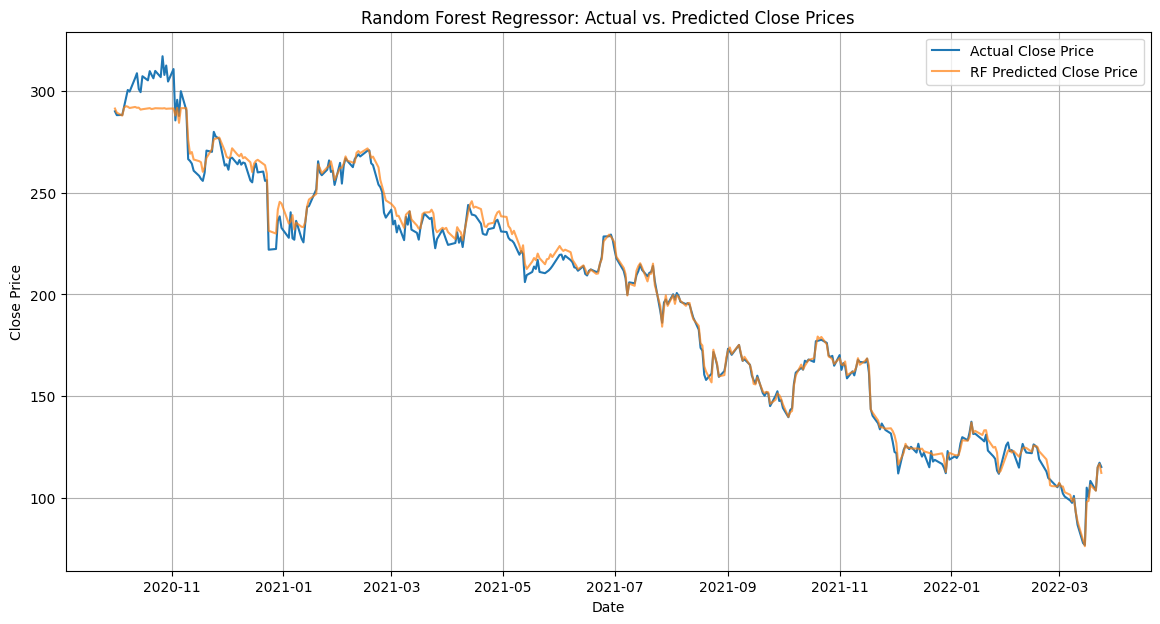

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Define features (X) and target (y)
features = [
    'Open', 'High', 'Low', 'Volume',
    'Close_Lag_1', 'Close_Lag_2', 'Close_Lag_3', 'Close_Lag_4', 'Close_Lag_5',
    'Volume_Lag_1', 'Volume_Lag_2', 'Volume_Lag_3', 'Volume_Lag_4', 'Volume_Lag_5',
    'Close_MA_7', 'Close_Std_7', 'Volume_MA_7',
    'Close_MA_30', 'Close_Std_30', 'Volume_MA_30',
    'Year', 'Month', 'Day', 'DayOfWeek', 'DayOfYear', 'WeekOfYear'
]
y = df_features['Close']
X = df_features[features]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
rf_predictions = rf_model.predict(X_test)

# Evaluate the model
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_mae = mean_absolute_error(y_test, rf_predictions)

print(f"Random Forest Regressor RMSE: {rf_rmse:.4f}")
print(f"Random Forest Regressor MAE: {rf_mae:.4f}")

# Plot actual vs. predicted prices
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Actual Close Price')
plt.plot(y_test.index, rf_predictions, label='RF Predicted Close Price', alpha=0.7)
plt.title('Random Forest Regressor: Actual vs. Predicted Close Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

**XGBoost Regressor Model**

XGBoost Regressor RMSE: 5.2327
XGBoost Regressor MAE: 3.2264


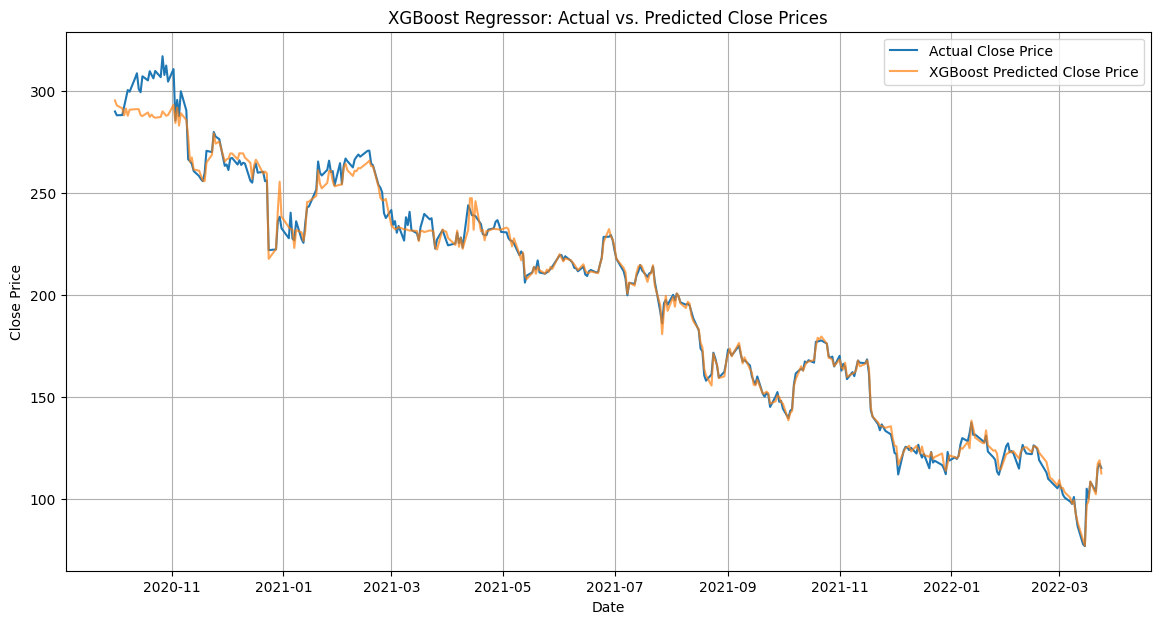

In [21]:
# Initialize and train the XGBoost Regressor model

import xgboost as xgb
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
xgb_predictions = xgb_model.predict(X_test)

# Evaluate the model
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_mae = mean_absolute_error(y_test, xgb_predictions)

print(f"XGBoost Regressor RMSE: {xgb_rmse:.4f}")
print(f"XGBoost Regressor MAE: {xgb_mae:.4f}")

# Plot actual vs. predicted prices
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Actual Close Price')
plt.plot(y_test.index, xgb_predictions, label='XGBoost Predicted Close Price', alpha=0.7)
plt.title('XGBoost Regressor: Actual vs. Predicted Close Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

**Support Vector Machine (SVM) Regressor Model**

SVM Regressor RMSE: 2.2355
SVM Regressor MAE: 1.7427


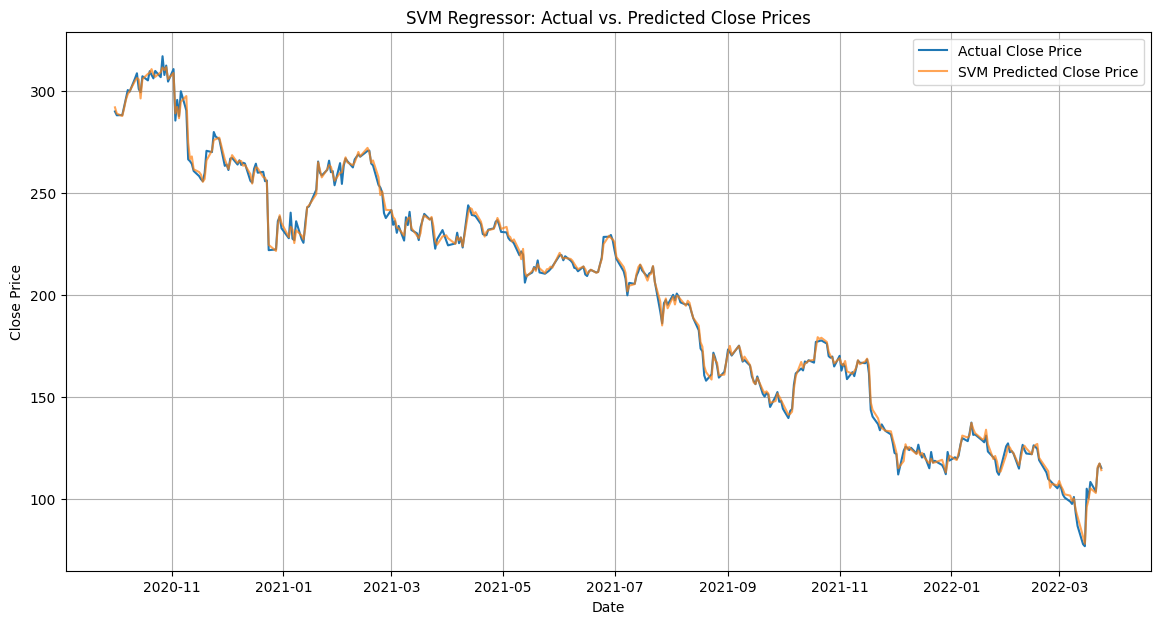

In [22]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Scale the features for SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the SVM Regressor model
# Using a linear kernel for simplicity, can be adjusted to 'rbf' for non-linear relationships
svm_model = SVR(kernel='linear', C=1.0, epsilon=0.1)
svm_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
svm_predictions = svm_model.predict(X_test_scaled)

# Evaluate the model
svm_rmse = np.sqrt(mean_squared_error(y_test, svm_predictions))
svm_mae = mean_absolute_error(y_test, svm_predictions)

print(f"SVM Regressor RMSE: {svm_rmse:.4f}")
print(f"SVM Regressor MAE: {svm_mae:.4f}")

# Plot actual vs. predicted prices
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Actual Close Price')
plt.plot(y_test.index, svm_predictions, label='SVM Predicted Close Price', alpha=0.7)
plt.title('SVM Regressor: Actual vs. Predicted Close Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

**Long Short-Term Memory (LSTM) Networks Model**

c:\Users\admin\OneDrive\Desktop\Alibaba\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 0.0149
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0022
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0026
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0022
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0019
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0019
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0019
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0017
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0018
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0017
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0018
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0016
Epoch 13/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0016
Epoch 14/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0016
Epoch 15/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0015
Epoc

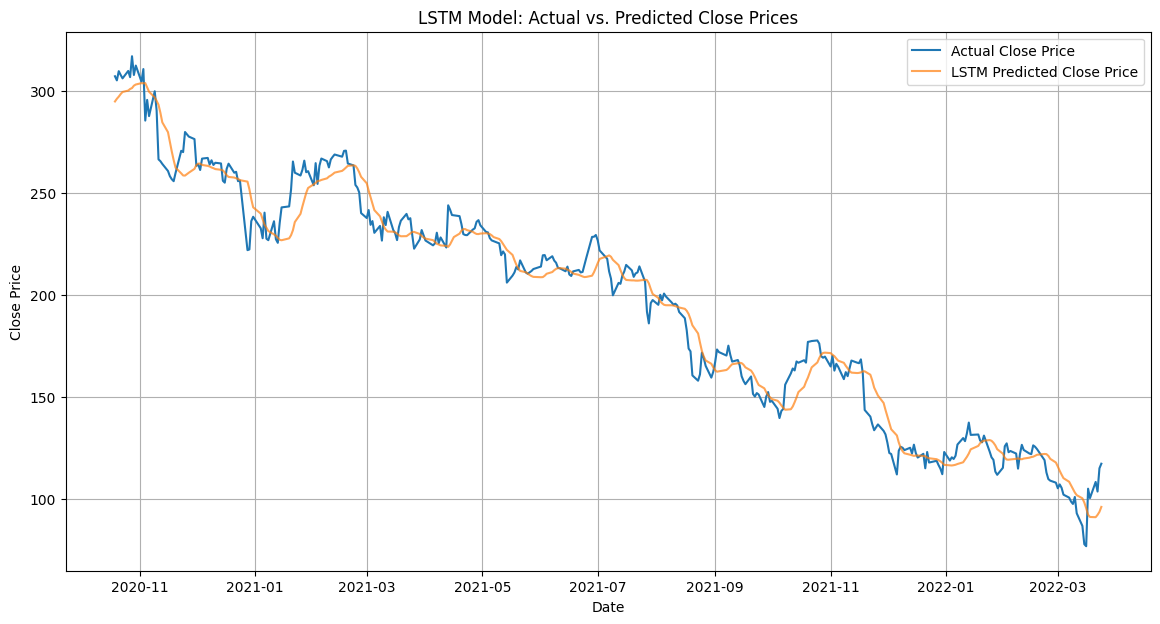

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

# Prepare data for LSTM
# LSTM typically works best with sequences and scaled data.
# We will use 'Close' price as the primary feature for simplicity in this example.

# Use only the 'Close' price for LSTM input for a simple example.
# For a more complex model, you can include other features after scaling.

data_for_lstm = df_features['Close'].values.reshape(-1, 1)

# Scale the data
scaler_lstm = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler_lstm.fit_transform(data_for_lstm)

# Create sequences for LSTM
def create_sequences(data, time_step):
    X_seq, y_seq = [], []
    for i in range(len(data) - time_step - 1):
        a = data[i:(i + time_step), 0]
        X_seq.append(a)
        y_seq.append(data[i + time_step, 0])
    return np.array(X_seq), np.array(y_seq)

time_step = 60 # Using 60 previous days to predict the next day
X_lstm, y_lstm = create_sequences(data_scaled, time_step)

# Split data into training and testing sets
# Splitting maintaining time order is crucial for time series
train_size = int(len(X_lstm) * 0.8)
X_train_lstm, X_test_lstm = X_lstm[0:train_size], X_lstm[train_size:len(X_lstm)]
y_train_lstm, y_test_lstm = y_lstm[0:train_size], y_lstm[train_size:len(y_lstm)]

# Reshape input to be [samples, time_steps, features] which is required for LSTM
X_train_lstm = X_train_lstm.reshape(X_train_lstm.shape[0], X_train_lstm.shape[1], 1)
X_test_lstm = X_test_lstm.reshape(X_test_lstm.shape[0], X_test_lstm.shape[1], 1)

# Build the LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(units=50, return_sequences=True, input_shape=(time_step, 1)))
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(units=50, return_sequences=False))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(units=1))

lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# Train the LSTM model
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=20, batch_size=32, verbose=1)

# Make predictions
lstm_predictions_scaled = lstm_model.predict(X_test_lstm)

# Inverse transform the predictions to get actual prices
lstm_predictions = scaler_lstm.inverse_transform(lstm_predictions_scaled)
y_test_lstm_inv = scaler_lstm.inverse_transform(y_test_lstm.reshape(-1, 1))

# Evaluate the model
lstm_rmse = np.sqrt(mean_squared_error(y_test_lstm_inv, lstm_predictions))
lstm_mae = mean_absolute_error(y_test_lstm_inv, lstm_predictions)

print(f"LSTM Model RMSE: {lstm_rmse:.4f}")
print(f"LSTM Model MAE: {lstm_mae:.4f}")

# Plot actual vs. predicted prices
# To align the dates, we need to consider the time_step and training size
predicted_dates = df_features.index[-len(y_test_lstm_inv):]

plt.figure(figsize=(14, 7))
plt.plot(predicted_dates, y_test_lstm_inv, label='Actual Close Price')
plt.plot(predicted_dates, lstm_predictions, label='LSTM Predicted Close Price', alpha=0.7)
plt.title('LSTM Model: Actual vs. Predicted Close Prices')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

**Summary of the above Models**


**Random Forest Regressor**:
RMSE: 5.0326;
MAE: 3.3915

**XGBoost Regressor**:
RMSE: 5.2327;
MAE: 3.2264

**Support Vector Machine (SVM) Regressor**:
RMSE: 2.2355;
MAE: 1.7427

**Long Short-Term Memory (LSTM) Networks**:
RMSE: 9.7640;
MAE: 7.4665

**Comparison and Conclusion:**

- Based on these metrics, the Support Vector Machine (SVM) Regressor performed the best with the lowest RMSE (2.2355) and MAE (1.7427). This indicates that the SVM model made the most accurate predictions with the smallest average error compared to the other models.

- The Random Forest and XGBoost models showed comparable performance, while the LSTM model, in this particular setup and with 20 epochs, had the highest RMSE and MAE, suggesting it was the least accurate among the four.
- It's possible that with more extensive hyperparameter tuning, more complex features, or longer training, the LSTM model's performance could improve.

**Saving the Trained SVM Model and Scaler**

In [24]:
import joblib

# Save the trained SVM model
joblib.dump(svm_model, 'svm_model.pkl')
print("SVM model saved as svm_model.pkl")

# Save the StandardScaler fitted to the training data
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved as scaler.pkl")

SVM model saved as svm_model.pkl
Scaler saved as scaler.pkl
